In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from utils import *

In [9]:
df = pd.read_csv("clustered_data.csv", index_col=0)
df.head()

,config,design,score,scaffold,time,in_pool,tcr_chain_index,mhc_chain_index,mhc_class,acdr1,...,cdr_len,gly_ala,receptor,mhc,antigen,cdr3a,cdr3b,cluster_a,cluster_b,cluster_ab
0,boltz:False\nmsa:True\ntemplates:False,7N2R+MAVMAPRTLV+TLMSAMTNL+CAVETGGGNK+CSARFGMNT...,26.515537,7N2R+MAVMAPRTLV+TLMSAMTNL+CAVETGGGNK+CSARFGMNTE_0,0.000000,False,"(0, 1)","(3,)",1,DSAIY,...,26,0.307692,7N2R,MAVMAPRTLV,TLMSAMTNL,CAVETGGGNK,CSARFGMNTE,NaN,NaN,NaN
1,boltz:False\nmsa:True\ntemplates:False,3QDG+MAVMAPRTLV+TLMSAMTNL+CAAAEAGNYQ+CASSRGTTN...,28.372200,3QDG+MAVMAPRTLV+TLMSAMTNL+CAAAEAGNYQ+CASSRGTTNT_0,0.000000,False,"(0, 1)","(3,)",1,DRGSQ,...,27,0.296296,3QDG,MAVMAPRTLV,TLMSAMTNL,CAAAEAGNYQ,CASSRGTTNT,NaN,NaN,NaN
2,boltz:False\nmsa:True\ntemplates:False,5BS0+MAVMAPRTLV+TLMSAMTNL+CAVETGGGNK+CSARFGMNT...,28.792614,5BS0+MAVMAPRTLV+TLMSAMTNL+CAVETGGGNK+CSARFGMNTE_0,0.016667,False,"(0, 1)","(3,)",1,DSAIY,...,26,0.153846,5BS0,MAVMAPRTLV,TLMSAMTNL,CAVETGGGNK,CSARFGMNTE,NaN,NaN,NaN
3,boltz:False\nmsa:True\ntemplates:False,1OGA+MAVMAPRTLV+TLMSAMTNL+CAALNGNNRL+CASSDSDRD...,29.627070,1OGA+MAVMAPRTLV+TLMSAMTNL+CAALNGNNRL+CASSDSDRDI_0,0.116667,False,"(0, 1)","(3,)",1,SSVF,...,25,0.160000,1OGA,MAVMAPRTLV,TLMSAMTNL,CAALNGNNRL,CASSDSDRDI,NaN,NaN,NaN
4,boltz:False\nmsa:True\ntemplates:False,3QDG+MAVMAPRTLV+TLMSAMTNL+CAAKGTGANS+CASSQEEGW...,26.649557,3QDG+MAVMAPRTLV+TLMSAMTNL+CAAKGTGANS+CASSQEEGWA_0,0.800000,False,"(0, 1)","(3,)",1,DRGSQ,...,28,0.214286,3QDG,MAVMAPRTLV,TLMSAMTNL,CAAKGTGANS,CASSQEEGWA,NaN,NaN,NaN


In [17]:
def plot(data, **kws):
    ax = plt.gca()
    cluster_cols = kws.get("cluster_cols", ["acdr3"])
    if len(cluster_cols)>1:
        get_logo(data[cluster_cols].apply(lambda x: "I".join(x.to_list()), axis=1).values, color_scheme=kws.get("color_scheme", "hydrophobicity"), ax=ax)
    else:
        cluster_cols = cluster_cols[0]
        get_logo(data[cluster_cols].values, color_scheme=kws.get("color_scheme", "hydrophobicity"), ax=ax)


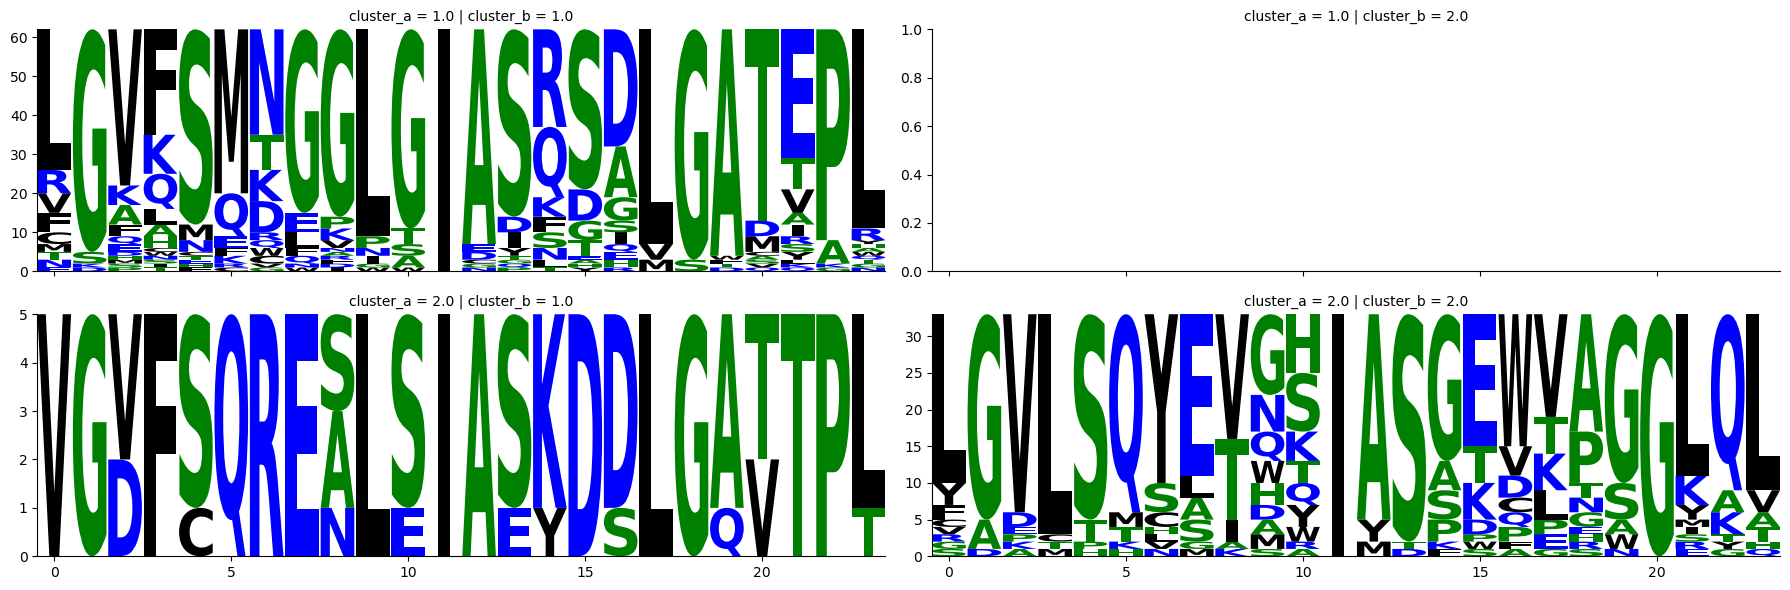

In [18]:
fig = plt.Figure()
grid = sns.FacetGrid(df.loc[df["in_pool"]],col="cluster_b", row="cluster_a", sharey=False, height=3, aspect=3)
#grid.map(lambda **kwargs: plt.grid(True, axis="y"))
#grid.map_dataframe(sns.violinplot, "receptor", "score",palette="tab10")
#grid.map_dataframe(lambda a,b,**kwargs: print(f"{a}:{b}"), "receptor", "score",palette="tab10")
grid.map_dataframe(plot, cluster_cols=["acdr3","bcdr3"])
